In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Classification

## Second Target (Multivariate Class Classification): titleType

In [46]:
sns.set(style="whitegrid")
sns.set_theme(palette='viridis')

# Load the preprocessed data
data_train = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_train.csv')
data_test = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
data_train['titleType'] = data_train['titleType'].fillna(8.0)
data_test['titleType'] = data_test['titleType'].fillna(8.0)

data_train.info()
data_train.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13943 entries, 0 to 13942
Columns: 205 entries, originalTitle to ZW
dtypes: float64(8), int64(196), object(1)
memory usage: 21.8+ MB


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,0.500000,6.659294,3.091042,0.693147,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Idealnaya para,6,1992,1.500000,3.663562,3.218876,0.000000,1,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
2,MasterChef Celebrity México,6,2021,0.500000,2.772589,4.043051,0.000000,0,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,Lightdance,9,1995,0.566667,2.708050,0.000000,0.000000,7,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
4,"Kiss, Kiss Bang, Bang",8,1995,0.750000,4.574711,4.709530,0.000000,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
5,Estrela de Oito Pontas,8,1996,0.200000,2.564949,1.098612,0.000000,8,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
6,JJBA Mangabridged: Phantom Blood 2 of 2,9,2017,0.733333,3.526361,1.791759,0.000000,3,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,Golubaya chashka,7,1965,1.000000,3.218876,3.610918,0.000000,1,1.386294,0.000000,...,0,0,0,0,0,0,0,0,0,0
8,The Formula,3,2014,1.500000,6.637258,4.955827,0.693147,1,1.791759,1.609438,...,0,0,0,0,0,0,0,0,0,0
9,Kako ubiv svetec,7,2004,1.366667,5.777652,4.442651,0.693147,1,1.945910,1.098612,...,0,0,0,0,0,0,0,0,0,0


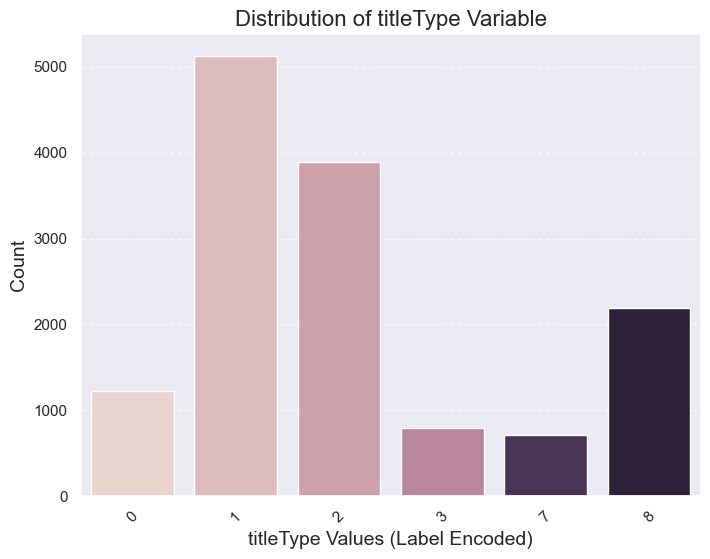

In [47]:
# Calculate the frequency of each unique value in 'titleType'
titleType_counts = data_train['titleType'].value_counts()

# Create a bar plot to visualize the distribution
plt.figure(figsize=(8, 6))  # Set the figure size
sns.barplot(x=titleType_counts.index, y=titleType_counts.values, hue =titleType_counts.index, legend=False)  # Plot the bar chart

# Customize the plot
plt.title('Distribution of titleType Variable', fontsize=16)  # Add a title
plt.xlabel('titleType Values (Label Encoded)', fontsize=14)  # Label for x-axis
plt.ylabel('Count', fontsize=14)  # Label for y-axis
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines for clarity
plt.show()  # Display the plot


In [48]:
selected_columns = ['runtimeMinutes', 'numVotes', 'rating', 'totalCredits', 'totalMedia', 'criticReviewsTotal',
                    'Adult', 'numRegions', 'NumberOfCountryoforigin', 'totalRecognitions', 'NumberOfGenres',
                    'startYearDecade', 'startYear', 'titleType']

df_selected = data_train[selected_columns]

# Step 3: Calculate the correlation of 'titleType' with each of the selected columns
correlation_titleType = df_selected.corr()['titleType'].drop('titleType')  # Dropping 'titleType' from the result

# Step 6: Print correlation values
print(correlation_titleType)

runtimeMinutes            -0.488132
numVotes                  -0.270568
rating                     0.021081
totalCredits              -0.431615
totalMedia                -0.270240
criticReviewsTotal        -0.193922
Adult                      0.149325
numRegions                -0.292864
NumberOfCountryoforigin   -0.076531
totalRecognitions         -0.040520
NumberOfGenres             0.098105
startYearDecade           -0.049720
startYear                 -0.048961
Name: titleType, dtype: float64


## KNN

In [49]:
# List of columns to include for k-NN
# After a research, this selection of columns provided the best result
selected_columns = [
    'runtimeMinutes', 'numVotes', 'totalCredits', 'totalRecognitions',
    'criticReviewsTotal', 'Adult', 'numRegions', 'totalMedia'
]

# Define features and target
X_train_knn = data_train[selected_columns]
y_train_knn = data_train['titleType']

X_test_knn = data_test[selected_columns]
y_test_knn = data_test['titleType']

X_train_knn.head()

,runtimeMinutes,numVotes,totalCredits,totalRecognitions,criticReviewsTotal,Adult,numRegions,totalMedia
0,0.500000,6.659294,3.091042,0.0,0.693147,0,0.693147,0.693147
1,1.500000,3.663562,3.218876,0.0,0.000000,0,0.693147,0.693147
2,0.500000,2.772589,4.043051,0.0,0.000000,0,0.693147,3.135494
3,0.566667,2.708050,0.000000,0.0,0.000000,0,0.693147,0.693147
4,0.750000,4.574711,4.709530,0.0,0.000000,0,0.693147,1.791759


To remember the Label Encoding of titleType:  
tvSeries -> 0  
movie -> 1  
tvEpisode -> 2  
tvMovie -> 3  
video -> 7  
short -> 8

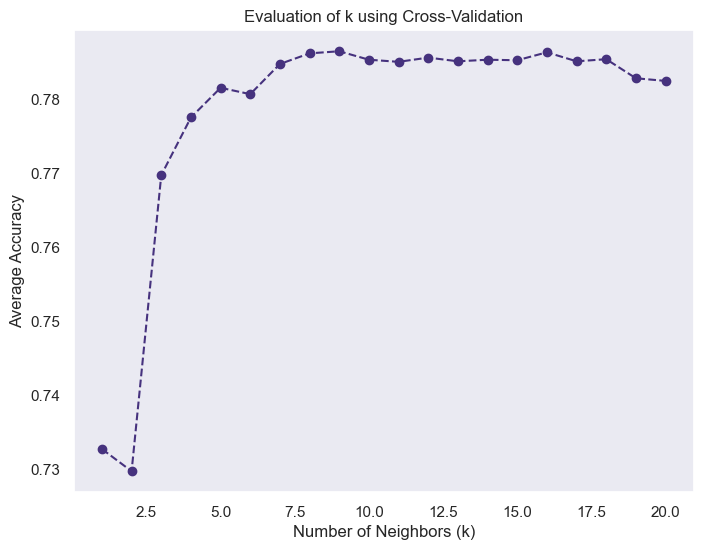

In [50]:
# Search for the best k value
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [51]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 9


In [52]:
# Train the model with the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

# Evaluate performance metrics
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred, average=None)
recall = recall_score(y_test_knn, y_pred, average=None)
f1 = f1_score(y_test_knn, y_pred, average=None)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.78
Precision: [0.6459144  0.82727273 0.78870432 0.27777778 0.59558824 0.7842031 ]
Recall: [0.40389294 0.93814433 0.89517345 0.05415162 0.37850467 0.83358321]
F1 Score: [0.49700599 0.87922705 0.83857294 0.09063444 0.46285714 0.80813953]


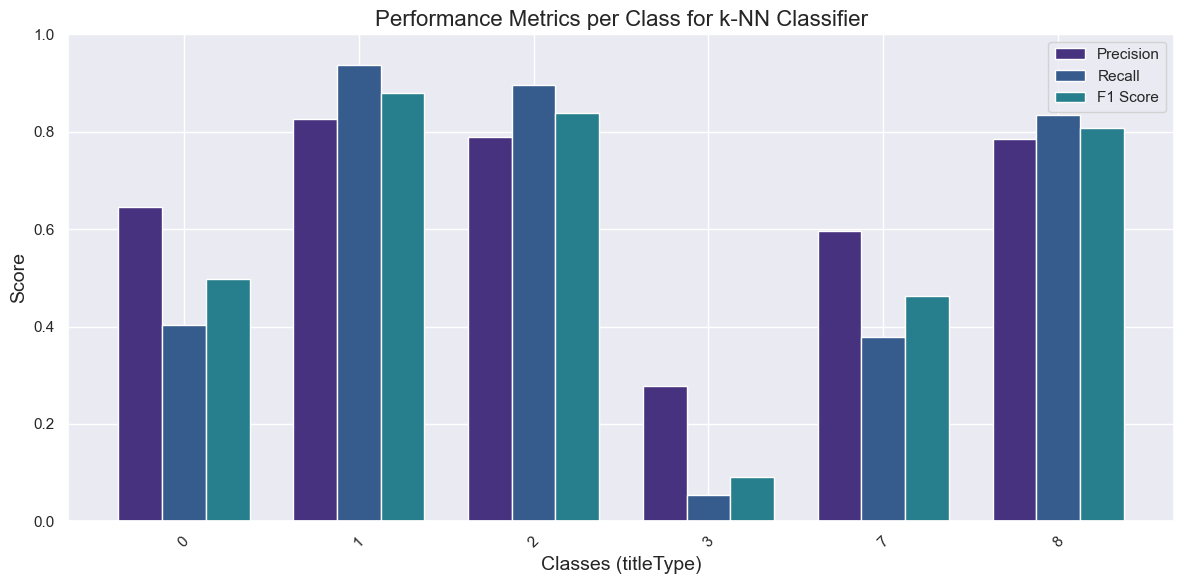

In [53]:
# Get class labels (assuming y_test_knn contains the class labels for 'titleType')
class_labels = np.unique(y_test_knn)

# Create a bar plot for precision, recall, and f1 score for each class
x = np.arange(len(class_labels))  # X-axis positions for the bars
width = 0.25  # Width of the bars

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each metric as a separate set of bars
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

# Customize the plot
plt.xlabel('Classes (titleType)', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Performance Metrics per Class for k-NN Classifier', fontsize=16)
plt.xticks(x, class_labels, rotation=45)  # Show class labels on the x-axis
plt.ylim(0, 1)  # Set the y-axis to range from 0 to 1
plt.legend()  # Add legend for the metrics

# Display the plot
plt.tight_layout()
plt.show()


It seems that KNN wasn't able to classify any record of classes 6 and 7, respectfully tvShort and TvSpecial (the two smallest classes in the dataset).

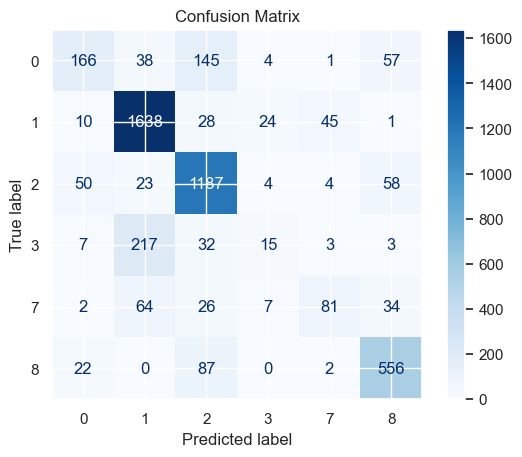

In [54]:
# Confusion matrix
cm = confusion_matrix(y_test_knn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [55]:
# Let's see the overall result
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred, average="weighted")
recall = recall_score(y_test_knn, y_pred, average="weighted")
f1 = f1_score(y_test_knn, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.78
Precision: 0.75
Recall: 0.78
F1 Score: 0.76


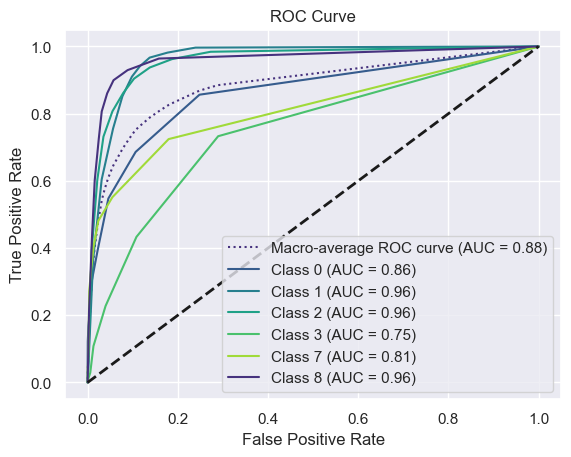

In [56]:
# Calcola le probabilità predette per ciascuna classe sul test set
y_prob = knn.predict_proba(X_test_knn)

# Dizionari per salvare FPR, TPR e AUC per ogni classe
fpr = {}
tpr = {}
roc_auc = {}

# Itera sulle classi effettive (es. 0, 1, 2, 3, 7, 8)
for cls in knn.classes_:
    # Se la classe non è presente nel test set, salta
    if np.sum(y_test_knn == cls) == 0:
        continue
    # Calcola la ROC per la classe corrente
    class_index = list(knn.classes_).index(cls)
    fpr[cls], tpr[cls], _ = roc_curve((y_test_knn == cls).astype(int), y_prob[:, class_index])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

# Calcolo della macro-media ROC (solo sulle classi presenti)
all_fpr = np.unique(np.concatenate([fpr[cls] for cls in roc_auc.keys()]))
mean_tpr = np.zeros_like(all_fpr)
for cls in roc_auc.keys():
    mean_tpr += np.interp(all_fpr, fpr[cls], tpr[cls])
mean_tpr /= len(roc_auc)
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot
plt.figure()
plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC curve (AUC = {roc_auc_macro:.2f})', linestyle=':')
for cls in roc_auc.keys():
    plt.plot(fpr[cls], tpr[cls], label=f'Class {cls} (AUC = {roc_auc[cls]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Linea random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()


## Naive Bayes


In [57]:
# List of columns to include for Gaussian Naive Bayes
# After a research, this selection of columns provided the best result
selected_columns = [
    'runtimeMinutes', 'rating', 'totalCredits','numRegions', 'startYear'
]

# Define features and target
X_train_gnb = data_train[selected_columns]
y_train_gnb = data_train['titleType']

X_test_gnb = data_test[selected_columns]
y_test_gnb = data_test['titleType']

In [58]:
# after having tried with Gaussian, Complement and Multinomial, Gaussian gave the best results
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred = gnb.predict(X_test_gnb)

accuracy = accuracy_score(y_test_gnb, y_pred)
precision = precision_score(y_test_gnb, y_pred, average=None)
recall = recall_score(y_test_gnb, y_pred, average=None)
f1 = f1_score(y_test_gnb, y_pred, average=None)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.71
Precision: [0.72765957 0.87391556 0.59276018 0.33333333 0.22285714 0.90613718]
Recall: [0.41605839 0.86540664 0.98793363 0.01805054 0.18224299 0.37631184]
F1 Score: [0.52941176 0.86964029 0.74095023 0.03424658 0.20051414 0.53177966]


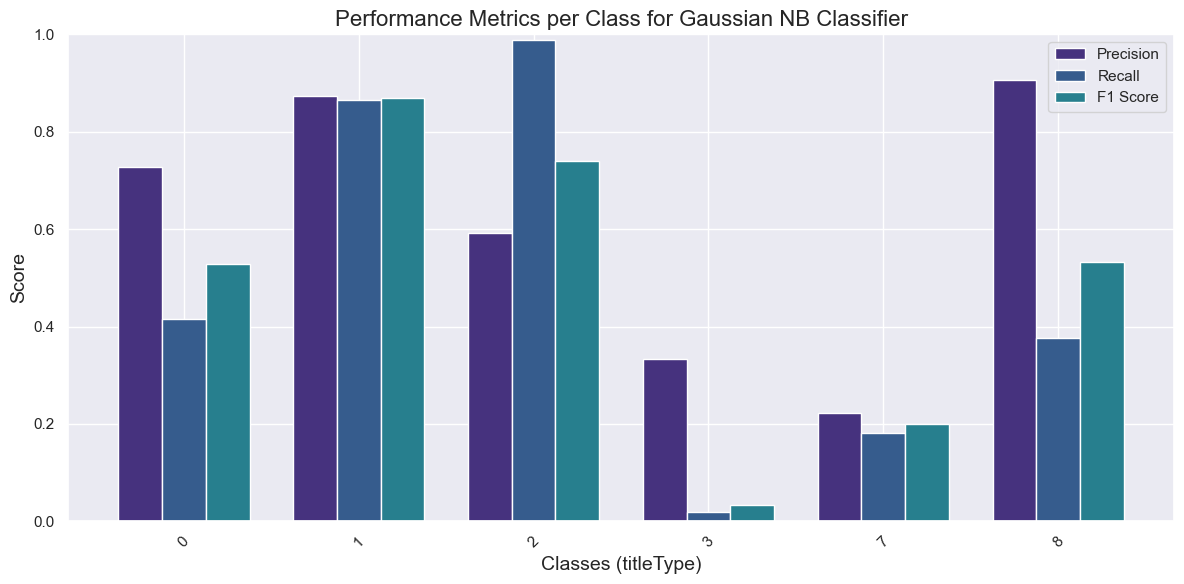

In [59]:
# Get class labels (assuming y_test_gnb contains the class labels for 'titleType')
class_labels = np.unique(y_test_gnb)

# Create a bar plot for precision, recall, and f1 score for each class
x = np.arange(len(class_labels))  # X-axis positions for the bars
width = 0.25  # Width of the bars

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each metric as a separate set of bars
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

# Customize the plot
plt.xlabel('Classes (titleType)', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Performance Metrics per Class for Gaussian NB Classifier', fontsize=16)
plt.xticks(x, class_labels, rotation=45)  # Show class labels on the x-axis
plt.ylim(0, 1)  # Set the y-axis to range from 0 to 1
plt.legend()  # Add legend for the metrics

# Display the plot
plt.tight_layout()
plt.show()

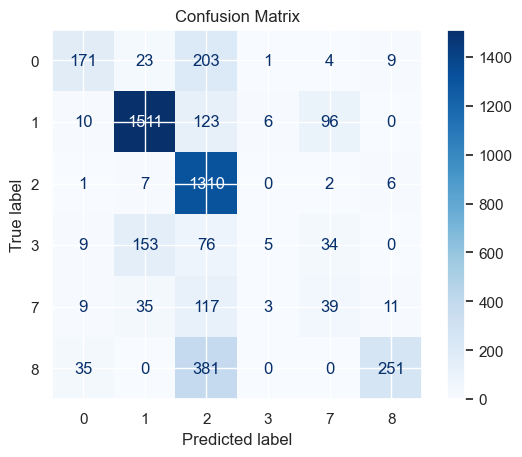

In [60]:
# Confusion matrix
cm = confusion_matrix(y_test_knn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [61]:
# Let's see the overall result
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred, average="weighted")
recall = recall_score(y_test_knn, y_pred, average="weighted")
f1 = f1_score(y_test_knn, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.71
Precision: 0.72
Recall: 0.71
F1 Score: 0.67


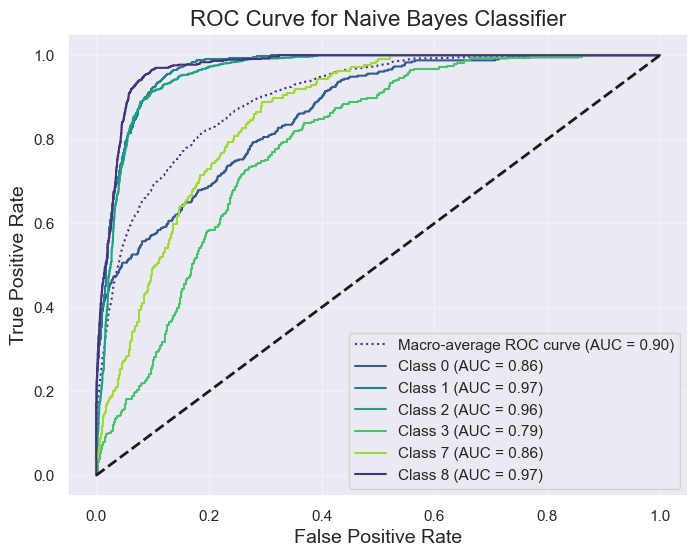

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Calculate predicted probabilities
y_prob = gnb.predict_proba(X_test_gnb)

# Initialize dictionaries for False Positive Rate, True Positive Rate, and AUC
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curve and AUC for each class (only if present in the test set)
for cls in gnb.classes_:
    if np.sum(y_test_gnb == cls) == 0:
        continue  # Skip class if not present in the test set
    class_index = list(gnb.classes_).index(cls)
    fpr[cls], tpr[cls], _ = roc_curve((y_test_gnb == cls).astype(int), y_prob[:, class_index])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

# Compute macro-average ROC curve (only using valid classes)
all_fpr = np.unique(np.concatenate([fpr[cls] for cls in roc_auc.keys()]))
mean_tpr = np.zeros_like(all_fpr)
for cls in roc_auc.keys():
    mean_tpr += np.interp(all_fpr, fpr[cls], tpr[cls])
mean_tpr /= len(roc_auc)
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plotting the ROC curves
plt.figure(figsize=(8, 6))

# Plot the macro-average ROC curve
plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC curve (AUC = {roc_auc_macro:.2f})', linestyle=':')

# Plot individual ROC curves for each valid class
for cls in roc_auc.keys():
    plt.plot(fpr[cls], tpr[cls], label=f'Class {cls} (AUC = {roc_auc[cls]:.2f})')

# Plot diagonal line (random classifier reference)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Customize plot appearance
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Naive Bayes Classifier', fontsize=16)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

## Decision Trees

In [63]:
# For Decision Trees, we'll use the not normalized datasets
not_normalized_data_train = pd.read_csv('data/output/02_data_understanding/clean_data_train.csv')
not_normalized_data_test = pd.read_csv('data/output/02_data_understanding/clean_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
not_normalized_data_train['titleType'] = not_normalized_data_train['titleType'].fillna(8.0)
not_normalized_data_test['titleType'] = not_normalized_data_test['titleType'].fillna(8.0)

# Define features and target
X_train_dt = not_normalized_data_train.drop(columns=['originalTitle', 'titleType'])
y_train_dt = not_normalized_data_train['titleType']

X_test_dt = not_normalized_data_test.drop(columns=['originalTitle', 'titleType'])
y_test_dt = not_normalized_data_test['titleType']

# Base model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Predictions
y_pred = dt.predict(X_test_dt)

# Score
print("Accuracy:", accuracy_score(y_test_dt, y_pred))
print("Classification Report:\n", classification_report(y_test_dt, y_pred)) 

Accuracy: 0.8375350140056023
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.71      0.72       411
           1       0.88      0.90      0.89      1746
           2       0.91      0.91      0.91      1326
           3       0.38      0.32      0.35       277
           7       0.50      0.50      0.50       214
           8       0.93      0.94      0.93       667

    accuracy                           0.84      4641
   macro avg       0.72      0.71      0.72      4641
weighted avg       0.83      0.84      0.84      4641



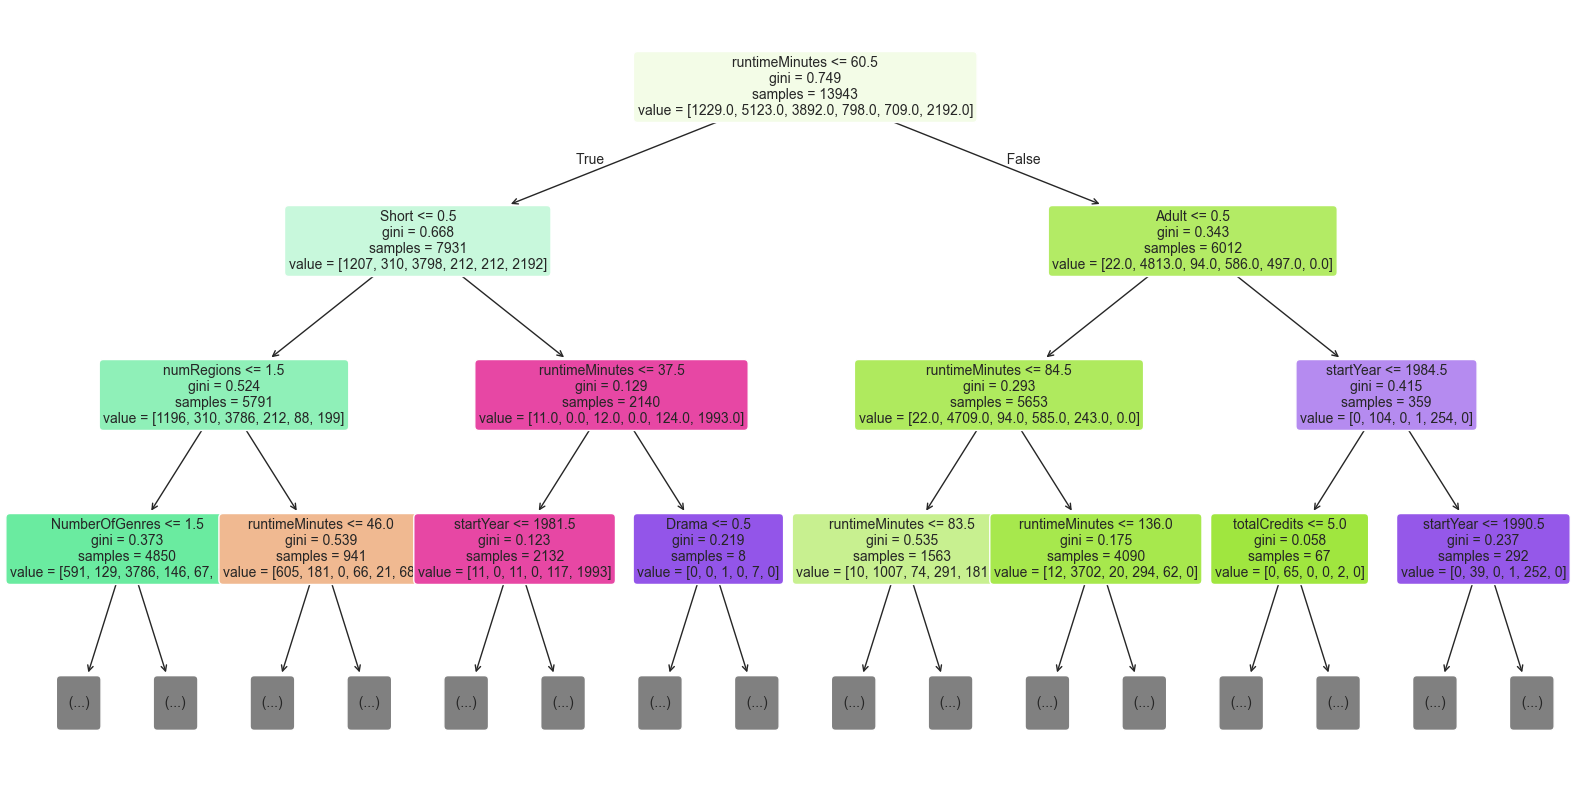

In [64]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X_train_dt.columns, filled=True, rounded=True, max_depth=3, fontsize=10)
plt.show()

In [65]:
# Hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],         # Funzione di split
    'max_depth': [3, 5, 10, None],            # Profondità massima
    'min_samples_split': [2, 5, 10],          # Split minimo
    'min_samples_leaf': [1, 2, 4],            # Foglie minime
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_best))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.64      0.73       411
           1       0.85      0.94      0.89      1746
           2       0.88      0.95      0.92      1326
           3       0.38      0.18      0.25       277
           7       0.66      0.44      0.53       214
           8       0.93      0.96      0.95       667

    accuracy                           0.85      4641
   macro avg       0.76      0.69      0.71      4641
weighted avg       0.83      0.85      0.84      4641



In [66]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV


# Definisci i parametri con distribuzioni casuali
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': randint(2, 20),  # Valori casuali tra 2 e 20
    'min_samples_leaf': randint(1, 10)    # Valori casuali tra 1 e 10
}

# RandomizedSearchCV con 50 iterazioni
random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=50,  # Numero di iterazioni
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   verbose=1)

random_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = random_search.best_params_
print("Best Parameters:", best_params)

best_dt = random_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_best))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 7, 'min_samples_split': 10}

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.64      0.72       411
           1       0.85      0.94      0.89      1746
           2       0.88      0.96      0.92      1326
           3       0.40      0.18      0.25       277
           7       0.72      0.40      0.51       214
           8       0.93      0.97      0.95       667

    accuracy                           0.85      4641
   macro avg       0.77      0.68      0.71      4641
weighted avg       0.83      0.85      0.84      4641



Optimized Accuracy: 0.8556345615169144
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.64      0.73       411
           1       0.84      0.95      0.89      1746
           2       0.88      0.96      0.92      1326
           3       0.41      0.15      0.22       277
           7       0.70      0.43      0.53       214
           8       0.93      0.98      0.95       667

    accuracy                           0.86      4641
   macro avg       0.77      0.68      0.71      4641
weighted avg       0.84      0.86      0.84      4641



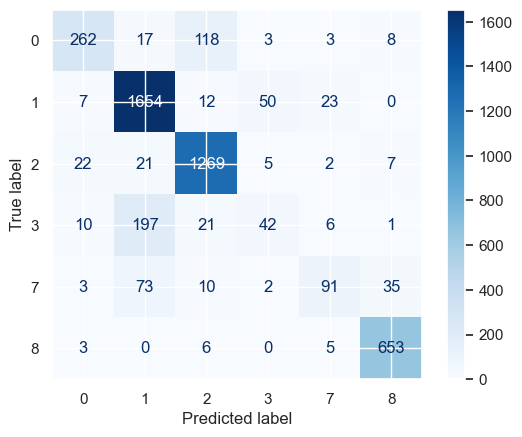

In [67]:
# Define the Decision Tree model with optimized parameters
dt_optimized = DecisionTreeClassifier(
    criterion='gini',           # Split criterion (information gain)
    max_depth=10,                  # Maximum depth of the tree
    min_samples_leaf=1,            # Minimum number of samples required for a leaf node
    min_samples_split=5,           # Minimum number of samples required to split a node
    random_state=42,                # Ensures reproducibility of results
    ccp_alpha= 0.00022819976672254407
)

# Train the model on the training dataset
dt_optimized.fit(X_train_dt, y_train_dt)

# Make predictions on the test dataset
y_pred_optimized = dt_optimized.predict(X_test_dt)

# Evaluate the model's performance
print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_optimized))  # Output overall accuracy
print("Classification Report:\n", classification_report(y_test_dt, y_pred_optimized))  # Detailed metrics

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test_dt, y_pred_optimized)

# Display the confusion matrix as a heatmap
ConfusionMatrixDisplay(conf_matrix, display_labels=dt_optimized.classes_).plot(cmap="Blues")

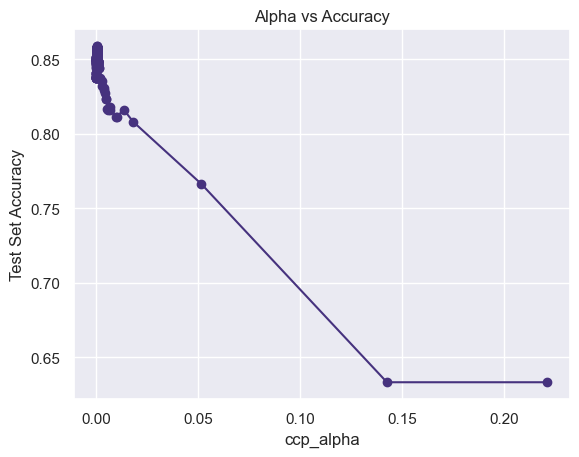

Best value of alpha: 0.0002370763505383025
Its Accuracy: 0.86


In [68]:
# Tuning of Alpha
path = dt_optimized.cost_complexity_pruning_path(X_train_dt, y_train_dt)
alphas = path.ccp_alphas  # Serie di valori di α
scores = []

# Testare ogni valore di α
best_alpha = None
best_score = -1

for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_dt, y_train_dt)
    score = clf.score(X_test_dt, y_test_dt)
    scores.append(score)
    
    # Identificare il miglior alpha
    if score > best_score:
        best_score = score
        best_alpha = alpha

# Visualizzare l'accuratezza in funzione di α
plt.plot(alphas, scores, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Test Set Accuracy')
plt.title('Alpha vs Accuracy')
plt.show()

# Stampare il miglior valore di alpha e l'accuratezza corrispondente
print(f"Best value of alpha: {best_alpha}")
print(f"Its Accuracy: {best_score:.2f}")

# The value of alpha was inserted above


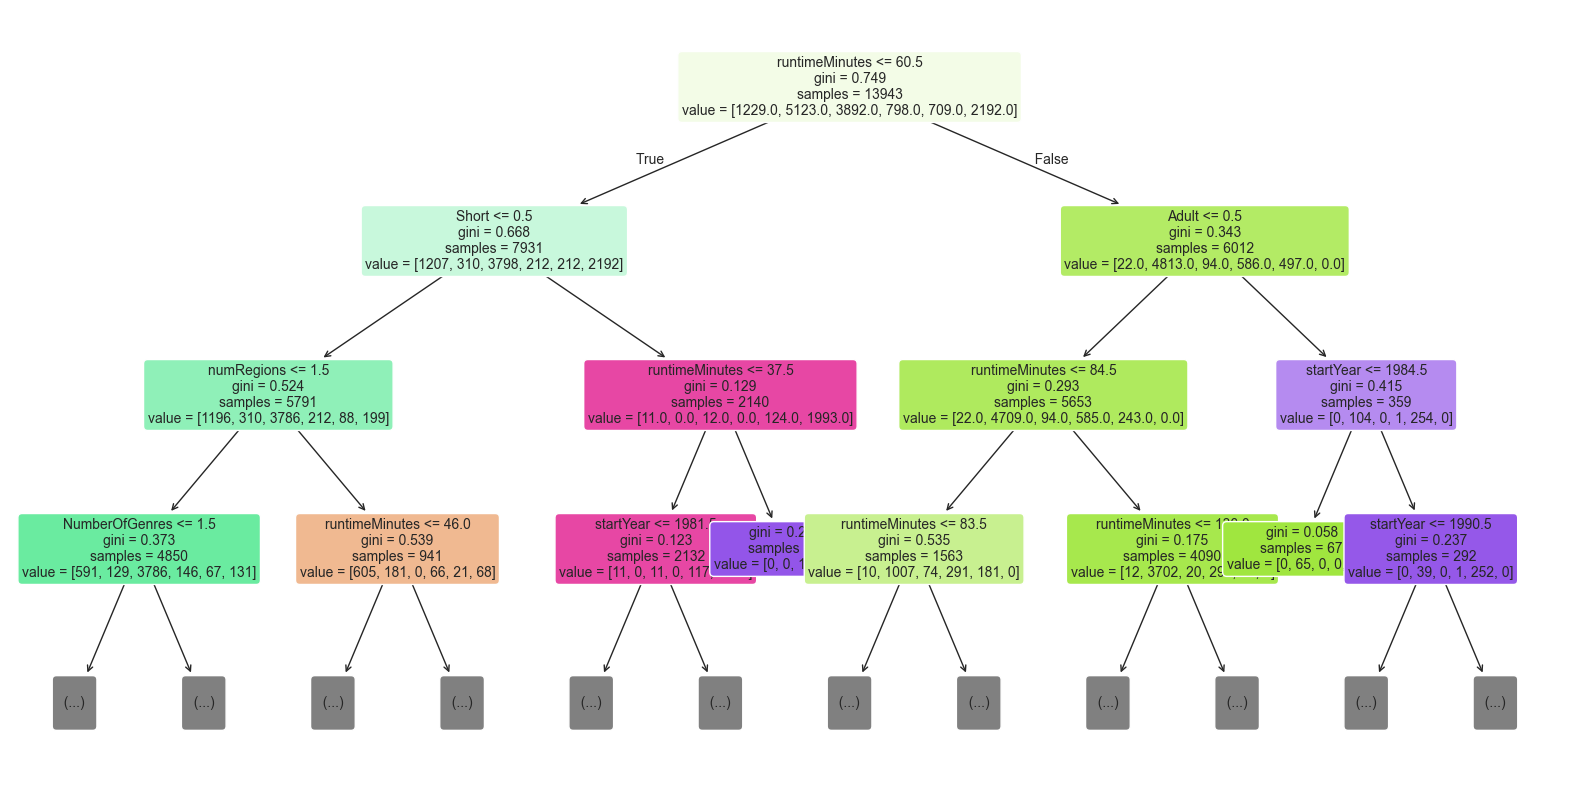

In [69]:
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, feature_names=X_train_dt.columns, filled=True, rounded=True, max_depth=3, fontsize=10)
plt.show()

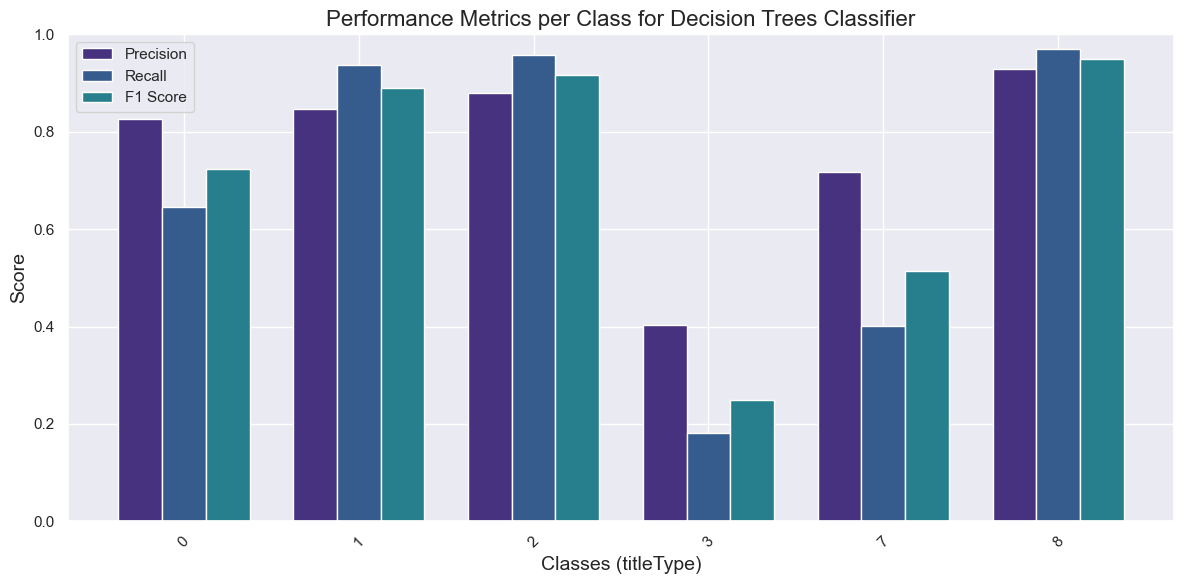

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# Calcola le metriche per ciascuna classe
class_labels = np.unique(y_test_dt)  # Ottieni le etichette di classe
precision = precision_score(y_test_dt, y_pred_best, average=None)
recall = recall_score(y_test_dt, y_pred_best, average=None)
f1 = f1_score(y_test_dt, y_pred_best, average=None)

# Posizioni sull'asse x
x = np.arange(len(class_labels))  # X-axis positions for the bars
width = 0.25  # Width of the bars

# Creazione del grafico
plt.figure(figsize=(12, 6))

# Grafico delle metriche
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

# Personalizzazione del grafico
plt.xlabel('Classes (titleType)', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Performance Metrics per Class for Decision Trees Classifier', fontsize=16)
plt.xticks(x, class_labels, rotation=45)  # Mostra le etichette delle classi sull'asse x
plt.ylim(0, 1)  # Imposta l'intervallo dell'asse y da 0 a 1
plt.legend()  # Aggiungi la legenda per le metriche

# Visualizzazione del grafico
plt.tight_layout()
plt.show()


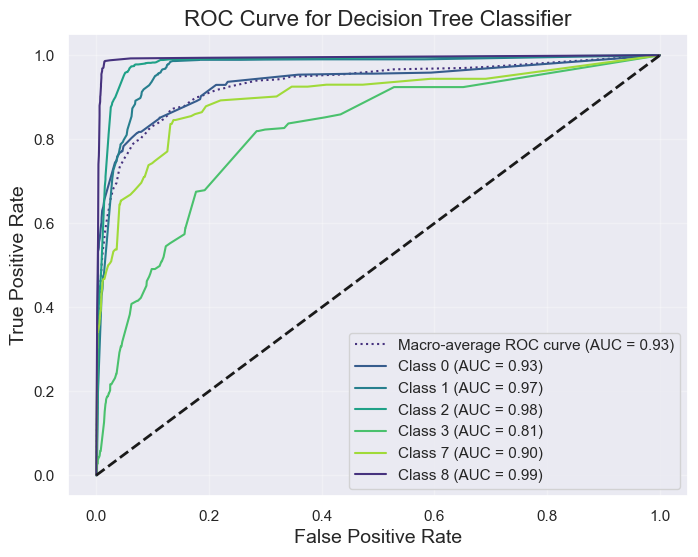

In [71]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predict class probabilities on the test set
y_prob = best_dt.predict_proba(X_test_dt)

# Initialize dictionaries for False Positive Rate, True Positive Rate, and AUC
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curves and AUC for each class (only if present in the test set)
for cls in best_dt.classes_:
    if np.sum(y_test_dt == cls) == 0:
        continue  # Skip class if not present in the test set
    class_index = list(best_dt.classes_).index(cls)
    fpr[cls], tpr[cls], _ = roc_curve((y_test_dt == cls).astype(int), y_prob[:, class_index])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

# Compute the macro-average ROC curve (only using valid classes)
all_fpr = np.unique(np.concatenate([fpr[cls] for cls in roc_auc.keys()]))
mean_tpr = np.zeros_like(all_fpr)
for cls in roc_auc.keys():
    mean_tpr += np.interp(all_fpr, fpr[cls], tpr[cls])
mean_tpr /= len(roc_auc)
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot the ROC curves
plt.figure(figsize=(8, 6))

# Macro-average ROC curve
plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC curve (AUC = {roc_auc_macro:.2f})', linestyle=':')

# Individual class ROC curves
for cls in roc_auc.keys():
    plt.plot(fpr[cls], tpr[cls], label=f'Class {cls} (AUC = {roc_auc[cls]:.2f})')

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Customize the plot
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Decision Tree Classifier', fontsize=16)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()
